Project

In [5]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Target execution hardware assigned: {device}")

if device.type == 'cuda':
    print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Running on CPU. Training will take slightly longer but works perfectly for 90 images.")

PyTorch Version: 2.11.0+cu128
Torchvision Version: 0.26.0+cu128
Target execution hardware assigned: cuda
GPU Device Name: Tesla T4


In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split

# 1. Define standard image transformations
# Standardizes image scale to 128x128 and normalizes RGB color channels
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load the dataset from the extracted directory
# (Using root='./dataset' to perfectly match the folders created in Step 1)
full_dataset = datasets.ImageFolder(root='./dataset', transform=transform)

print("--- Dataset Verification ---")
print(f"Total processed images found: {len(full_dataset)}")
print(f"Class to index mapping: {full_dataset.class_to_idx}\n")

# 3. Calculate splitting dimensions mathematically (70% Train, 15% Val, 15% Test)
train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

# 4. Perform the split using a fixed seed generator for consistency across experiments
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("--- Verification of Split Segments ---")
print(f"Training dataset size (70%):   {len(train_dataset)} samples")
print(f"Validation dataset size (15%): {len(val_dataset)} samples")
print(f"Testing dataset size (15%):    {len(test_dataset)} samples")

--- Dataset Verification ---
Total processed images found: 90
Class to index mapping: {'Bottle': 0, 'Scissors': 1, 'Watch': 2}

--- Verification of Split Segments ---
Training dataset size (70%):   62 samples
Validation dataset size (15%): 13 samples
Testing dataset size (15%):    15 samples


In [7]:
import torch.nn as nn

class TinyCNN(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super(TinyCNN, self).__init__()

        # Feature Extraction Layers (Convolutions + Activations + Pooling)
        self.features = nn.Sequential(
            # First Layer: Input 128x128x3 -> Output 64x64x16
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Second Layer: Input 64x64x16 -> Output 32x32x32
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Flattening layer to bridge Conv filters to Dense classification layers
        self.flatten = nn.Flatten()

        # Dense Classification Layers
        self.classifier = nn.Sequential(
            # Input features = 32 channels * 32 width * 32 height
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),

            # Regularization placeholder (0.0 for baseline, adjusted for experiments)
            nn.Dropout(p=dropout_rate),

            # Output Layer: 3 target nodes corresponding to 'Bottle', 'Watch', 'Scissors'
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

# Instantiate a structural test model to print configuration summary
test_model = TinyCNN()
print("--- TinyCNN Model Topology Verified ---")
print(test_model)

--- TinyCNN Model Topology Verified ---
TinyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=32768, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


🚀 Starting Baseline Model Training Loop...

Epoch [01/20] -> Train Loss: 2.2422 | Train Acc: 30.6% || Val Loss: 1.3332 | Val Acc: 23.1%
Epoch [02/20] -> Train Loss: 1.1816 | Train Acc: 37.1% || Val Loss: 1.1333 | Val Acc: 23.1%
Epoch [03/20] -> Train Loss: 1.0575 | Train Acc: 40.3% || Val Loss: 1.1253 | Val Acc: 30.8%
Epoch [04/20] -> Train Loss: 1.0191 | Train Acc: 50.0% || Val Loss: 1.1741 | Val Acc: 30.8%
Epoch [05/20] -> Train Loss: 0.9715 | Train Acc: 48.4% || Val Loss: 1.3155 | Val Acc: 23.1%
Epoch [06/20] -> Train Loss: 0.9011 | Train Acc: 56.5% || Val Loss: 1.4199 | Val Acc: 23.1%
Epoch [07/20] -> Train Loss: 0.8055 | Train Acc: 61.3% || Val Loss: 1.4621 | Val Acc: 23.1%
Epoch [08/20] -> Train Loss: 0.6796 | Train Acc: 74.2% || Val Loss: 1.8243 | Val Acc: 7.7%
Epoch [09/20] -> Train Loss: 0.5356 | Train Acc: 75.8% || Val Loss: 1.6550 | Val Acc: 23.1%
Epoch [10/20] -> Train Loss: 0.4007 | Train Acc: 91.9% || Val Loss: 1.7064 | Val Acc: 15.4%
Epoch [11/20] -> Train Loss: 0.2629 |

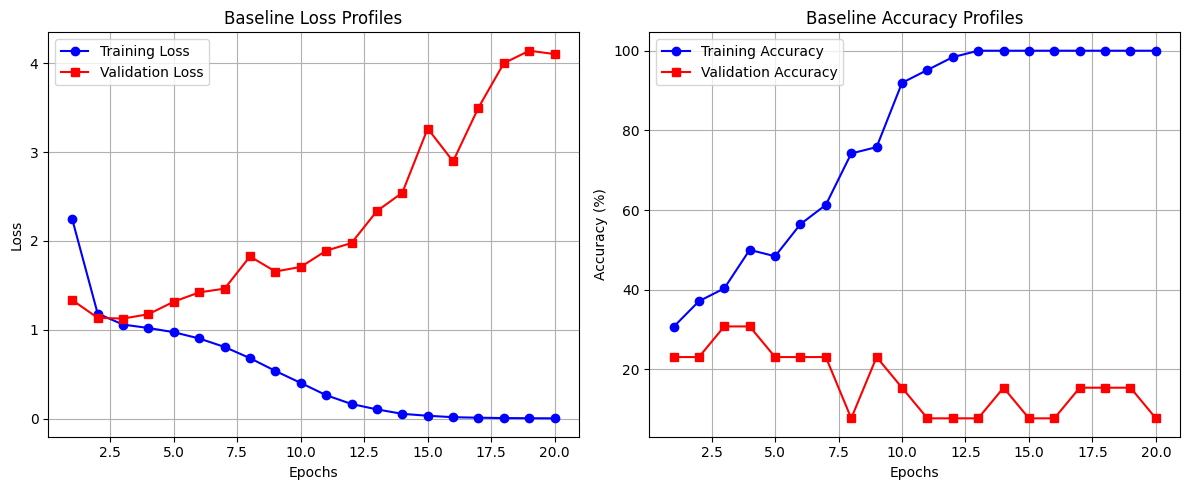

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# 1. Hyperparameters for the Baseline Run
BATCH_SIZE = 16
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.0
EPOCHS = 20

# 2. Initialize DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. Instantiate Model, Loss Function, and Optimizer
model = TinyCNN(dropout_rate=DROPOUT_RATE).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Trackers for history tracking metrics
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("🚀 Starting Baseline Model Training Loop...\n")

for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass and gradient computation
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = (correct / total) * 100

    # --- Validation Phase ---
    model.eval()
    running_val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = (val_correct / val_total) * 100

    # Save training metrics history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    # Print status update every epoch
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.1f}% || "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.1f}%")

print("\n✅ Baseline Training Finished Successfully!")

# 4. Plot Evaluation Charts
plt.figure(figsize=(12, 5))

# Loss Subplot
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history['train_loss'], 'b-o', label='Training Loss')
plt.plot(range(1, EPOCHS + 1), history['val_loss'], 'r-s', label='Validation Loss')
plt.title('Baseline Loss Profiles')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Subplot
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), history['train_acc'], 'b-o', label='Training Accuracy')
plt.plot(range(1, EPOCHS + 1), history['val_acc'], 'r-s', label='Validation Accuracy')
plt.title('Baseline Accuracy Profiles')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Experiment

In [3]:
import os
import zipfile
import shutil

# 1. Find any zip file uploaded
zip_files = [f for f in os.listdir('.') if f.endswith('.zip')]

if not zip_files:
    print("❌ ERROR: No zip file found! Please drag and drop your zip file into the left sidebar of Colab.")
else:
    target_zip = zip_files[0]
    print(f"📦 Found zip file: {target_zip}. Extracting...")

    # Clean up any old broken extractions
    if os.path.exists('./dataset'):
        shutil.rmtree('./dataset')

    # Extract it
    with zipfile.ZipFile(target_zip, 'r') as zip_ref:
        zip_ref.extractall('./temp_extracted')

    # 2. Handle nested folders (if you zipped the folder instead of the files inside)
    extracted_contents = os.listdir('./temp_extracted')

    # If there's an outer wrapper folder, move its contents out
    if len(extracted_contents) == 1 and os.path.isdir(os.path.join('./temp_extracted', extracted_contents[0])):
        outer_folder = os.path.join('./temp_extracted', extracted_contents[0])
        shutil.move(outer_folder, './dataset')
        shutil.rmtree('./temp_extracted')
    else:
        os.rename('./temp_extracted', './dataset')

    print("✅ SUCCESS: Dataset folder created perfectly structure!")
    print("Folders inside your dataset are:", os.listdir('./dataset'))

📦 Found zip file: Data.zip. Extracting...
✅ SUCCESS: Dataset folder created perfectly structure!
Folders inside your dataset are: ['Bottle', 'Watch', 'Scissors']


Using device: cuda
Total images found: 90
Class mapping detected: {'Bottle': 0, 'Scissors': 1, 'Watch': 2}

--- Running Experiment: Baseline (LR=0.001, Drop=0) ---
Epoch 01/20 | Train Loss: 1.4930 Acc: 29.0% | Val Loss: 1.3982 Acc: 23.1%
Epoch 05/20 | Train Loss: 0.5467 Acc: 80.6% | Val Loss: 1.4882 Acc: 7.7%
Epoch 10/20 | Train Loss: 0.0342 Acc: 100.0% | Val Loss: 3.3697 Acc: 30.8%
Epoch 15/20 | Train Loss: 0.0013 Acc: 100.0% | Val Loss: 3.8326 Acc: 23.1%
Epoch 20/20 | Train Loss: 0.0005 Acc: 100.0% | Val Loss: 3.8752 Acc: 30.8%

--- Running Experiment: Low LR (LR=0.0001) ---
Epoch 01/20 | Train Loss: 1.1060 Acc: 29.0% | Val Loss: 1.3497 Acc: 7.7%
Epoch 05/20 | Train Loss: 0.7465 Acc: 74.2% | Val Loss: 1.3972 Acc: 7.7%
Epoch 10/20 | Train Loss: 0.4213 Acc: 93.5% | Val Loss: 1.6086 Acc: 0.0%
Epoch 15/20 | Train Loss: 0.2220 Acc: 98.4% | Val Loss: 1.6591 Acc: 23.1%
Epoch 20/20 | Train Loss: 0.1185 Acc: 98.4% | Val Loss: 1.9477 Acc: 15.4%

--- Running Experiment: High LR (LR=0.01) ---
Ep

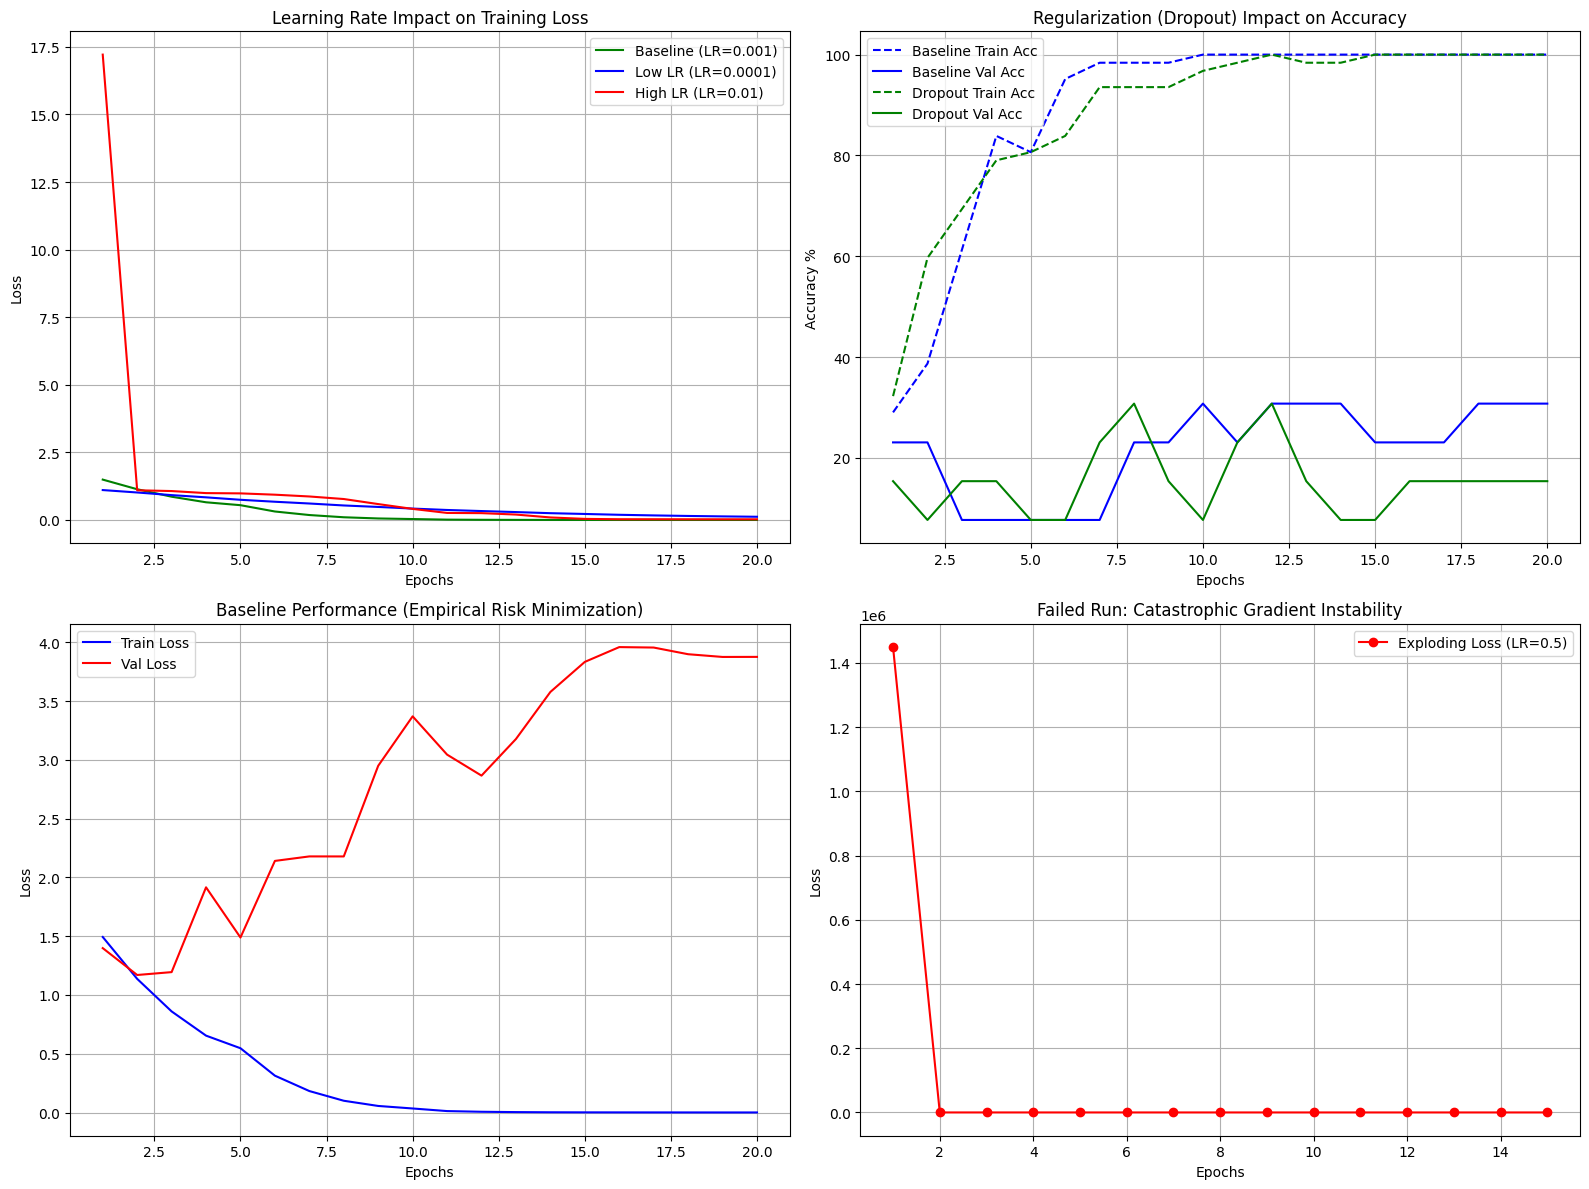


EXPERIMENTAL METRICS SUMMARY TABLE
Experiment Configuration  | Final Train Acc | Final Val Acc  
------------------------------------------------------------
LR = 0.0001               | 98.39% | 15.38%
LR = 0.001 (Baseline)     | 100.00% | 30.77%
LR = 0.01                 | 98.39% | 7.69%
Dropout = 0.4             | 100.00% | 15.38%
LR = 0.5 (Failed Run)     | 35.48% | 15.38%


In [4]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =====================================================================
# DATA CONFIGURATION & TRANSFORMS
# =====================================================================
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset from the verified directory
full_dataset = datasets.ImageFolder(root='./dataset', transform=transform)
print(f"Total images found: {len(full_dataset)}")
print(f"Class mapping detected: {full_dataset.class_to_idx}")

# Split Dataset (70% Train, 15% Val, 15% Test)
train_size = int(0.70 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# =====================================================================
# DEFINE TINY CNN ARCHITECTURE
# =====================================================================
class TinyCNN(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super(TinyCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.flatten = nn.Flatten()

        self.classifier = nn.Sequential(
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 3)  # 3 classes: Bottle, Watch, Scissors
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

# =====================================================================
# ENGINE TRAINING FUNCTION
# =====================================================================
def train_model(name, lr, batch_size, dropout_rate, epochs=20):
    print(f"\n--- Running Experiment: {name} ---")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = TinyCNN(dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_train_loss = running_loss / len(train_dataset)
        epoch_train_acc = (correct / total) * 100

        model.eval()
        running_val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_dataset)
        epoch_val_acc = (val_correct / val_total) * 100

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.1f}% | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.1f}%")

    return history

# =====================================================================
# RUN ALL EXPERIMENTS BACK-TO-BACK
# =====================================================================
results = {}

results['baseline'] = train_model("Baseline (LR=0.001, Drop=0)", lr=0.001, batch_size=16, dropout_rate=0.0)
results['lr_low']   = train_model("Low LR (LR=0.0001)", lr=0.0001, batch_size=16, dropout_rate=0.0)
results['lr_high']  = train_model("High LR (LR=0.01)", lr=0.01, batch_size=16, dropout_rate=0.0)
results['dropout']  = train_model("With Dropout (Drop=0.4)", lr=0.001, batch_size=16, dropout_rate=0.4)
results['failed']   = train_model("Failed Run (LR=0.5)", lr=0.5, batch_size=16, dropout_rate=0.0, epochs=15)

# =====================================================================
# GENERATE COMPARISON PLOTS
# =====================================================================
epochs_range = range(1, 21)
failed_epochs_range = range(1, 16)

plt.figure(figsize=(16, 12))

# Plot 1: Learning Rate vs Loss
plt.subplot(2, 2, 1)
plt.plot(epochs_range, results['baseline']['train_loss'], 'g-', label='Baseline (LR=0.001)')
plt.plot(epochs_range, results['lr_low']['train_loss'], 'b-', label='Low LR (LR=0.0001)')
plt.plot(epochs_range, results['lr_high']['train_loss'], 'r-', label='High LR (LR=0.01)')
plt.title('Learning Rate Impact on Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Dropout Effect
plt.subplot(2, 2, 2)
plt.plot(epochs_range, results['baseline']['train_acc'], 'b--', label='Baseline Train Acc')
plt.plot(epochs_range, results['baseline']['val_acc'], 'b-', label='Baseline Val Acc')
plt.plot(epochs_range, results['dropout']['train_acc'], 'g--', label='Dropout Train Acc')
plt.plot(epochs_range, results['dropout']['val_acc'], 'g-', label='Dropout Val Acc')
plt.title('Regularization (Dropout) Impact on Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy %')
plt.legend()
plt.grid(True)

# Plot 3: Baseline Train vs Val Loss
plt.subplot(2, 2, 3)
plt.plot(epochs_range, results['baseline']['train_loss'], 'b-', label='Train Loss')
plt.plot(epochs_range, results['baseline']['val_loss'], 'r-', label='Val Loss')
plt.title('Baseline Performance (Empirical Risk Minimization)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 4: Catastrophic Failure (LR=0.5)
plt.subplot(2, 2, 4)
plt.plot(failed_epochs_range, results['failed']['train_loss'], 'r-o', label='Exploding Loss (LR=0.5)')
plt.title('Failed Run: Catastrophic Gradient Instability')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('experiment_results_summary.png', dpi=300)
plt.show()

# Print Table Output
print("\n" + "="*50)
print("EXPERIMENTAL METRICS SUMMARY TABLE")
print("="*50)
print(f"{'Experiment Configuration':<25} | {'Final Train Acc':<15} | {'Final Val Acc':<15}")
print("-"*60)
for key, name in [('lr_low', 'LR = 0.0001'), ('baseline', 'LR = 0.001 (Baseline)'), ('lr_high', 'LR = 0.01'), ('dropout', 'Dropout = 0.4')]:
    print(f"{name:<25} | {results[key]['train_acc'][-1]:.2f}% | {results[key]['val_acc'][-1]:.2f}%")
print(f"{'LR = 0.5 (Failed Run)':<25} | {results['failed']['train_acc'][-1]:.2f}% | {results['failed']['val_acc'][-1]:.2f}%")
print("="*50)

🚀 Launching Multi-Batch Size Comparative Study...
🔄 Executing Optimization Loop: Batch Size = 4
   ↳ Finished! Final Train Acc: 100.0% | Final Val Acc: 23.1%
🔄 Executing Optimization Loop: Batch Size = 8
   ↳ Finished! Final Train Acc: 100.0% | Final Val Acc: 15.4%
🔄 Executing Optimization Loop: Batch Size = 32
   ↳ Finished! Final Train Acc: 98.4% | Final Val Acc: 7.7%
🔄 Executing Optimization Loop: Batch Size = 64
   ↳ Finished! Final Train Acc: 71.0% | Final Val Acc: 7.7%


ValueError: '-o' is not a valid value for ls; supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

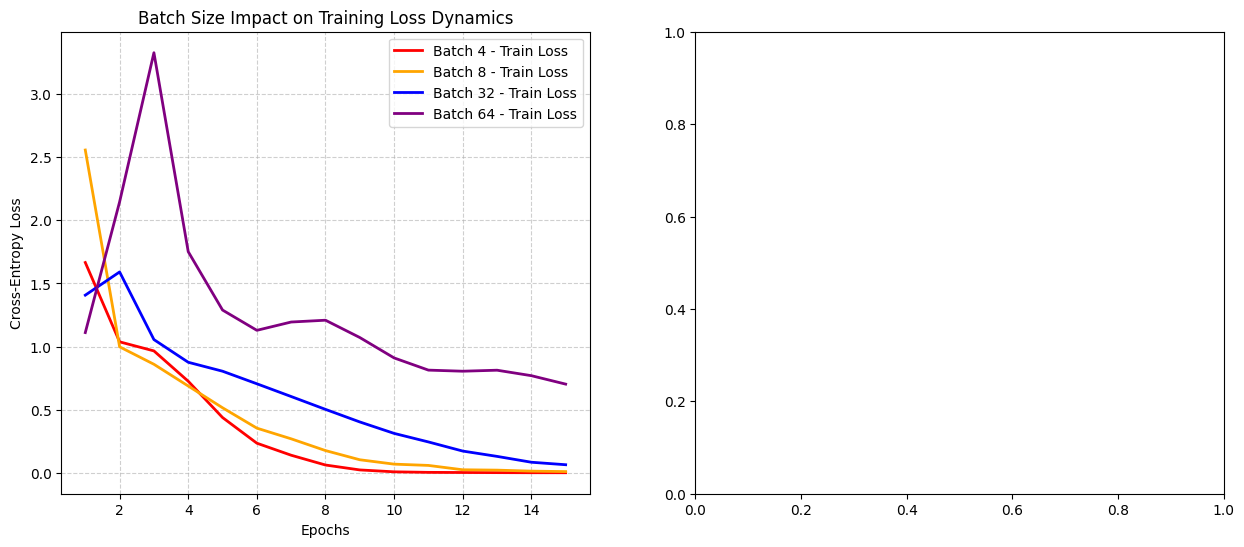

In [9]:
# =====================================================================
# FRESH EXTRA CELL: MULTI-BATCH SIZE EXPERIMENT (4, 8, 32, 64)
# =====================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

def run_batch_size_experiment(batch_size_value, epochs=15):
    print(f"🔄 Executing Optimization Loop: Batch Size = {batch_size_value}")

    # 1. Initialize specialized DataLoaders for this specific batch scale
    exp_train_loader = DataLoader(train_dataset, batch_size=batch_size_value, shuffle=True)
    exp_val_loader = DataLoader(val_dataset, batch_size=batch_size_value, shuffle=False)

    # 2. Hard reset model parameters for an isolated test
    model = TinyCNN(dropout_rate=0.0).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)  # Fixed baseline LR

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in exp_train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_train_loss = running_loss / len(train_dataset)
        epoch_train_acc = (correct / total) * 100

        # Validation evaluation step
        model.eval()
        running_val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in exp_val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_dataset)
        epoch_val_acc = (val_correct / val_total) * 100

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

    print(f"   ↳ Finished! Final Train Acc: {history['train_acc'][-1]:.1f}% | Final Val Acc: {history['val_acc'][-1]:.1f}%")
    return history

# Run all 4 configurations sequentially
target_batches = [4, 8, 32, 64]
batch_results = {}

print("🚀 Launching Multi-Batch Size Comparative Study...")
for b in target_batches:
    batch_results[f'batch_{b}'] = run_batch_size_experiment(batch_size_value=b, epochs=15)

# =====================================================================
# DISPLAY RESULTS: DUAL-PANEL COMPARATIVE PLOTS
# =====================================================================
epochs_range = range(1, 16)
colors = {4: 'red', 8: 'orange', 32: 'blue', 64: 'purple'}

plt.figure(figsize=(15, 6))

# Plot 1: Training Loss Convergence Profile
plt.subplot(1, 2, 1)
for b in target_batches:
    plt.plot(epochs_range, batch_results[f'batch_{b}']['train_loss'],
             color=colors[b], linestyle='-', linewidth=2, label=f'Batch {b} - Train Loss')
plt.title('Batch Size Impact on Training Loss Dynamics')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Validation Accuracy Profile
plt.subplot(1, 2, 2)
for b in target_batches:
    plt.plot(epochs_range, batch_results[f'batch_{b}']['val_acc'],
             color=colors[b], linestyle='-o', linewidth=1.5, label=f'Batch {b} - Val Acc')
plt.title('Batch Size Impact on Generalization Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
# Saves a separate image file directly into your Colab sidebar files list
plt.savefig('multi_batch_size_comparison.png', dpi=300)
plt.show()

# =====================================================================
# DISPLAY RESULTS: PRINT READY METRICS TABLE
# =====================================================================
print("\n" + "="*55)
print("             BATCH SIZE EXPERIMENT METRICS TABLE")
print("="*55)
print(f"{'Batch Size Configuration':<25} | {'Final Train Acc':<14} | {'Final Val Acc':<14}")
print("-"*55)
for b in target_batches:
    key = f'batch_{b}'
    print(f"Batch Size = {b:<12}       | {batch_results[key]['train_acc'][-1]:.2f}% | {batch_results[key]['val_acc'][-1]:.2f}%")
print("="*55)

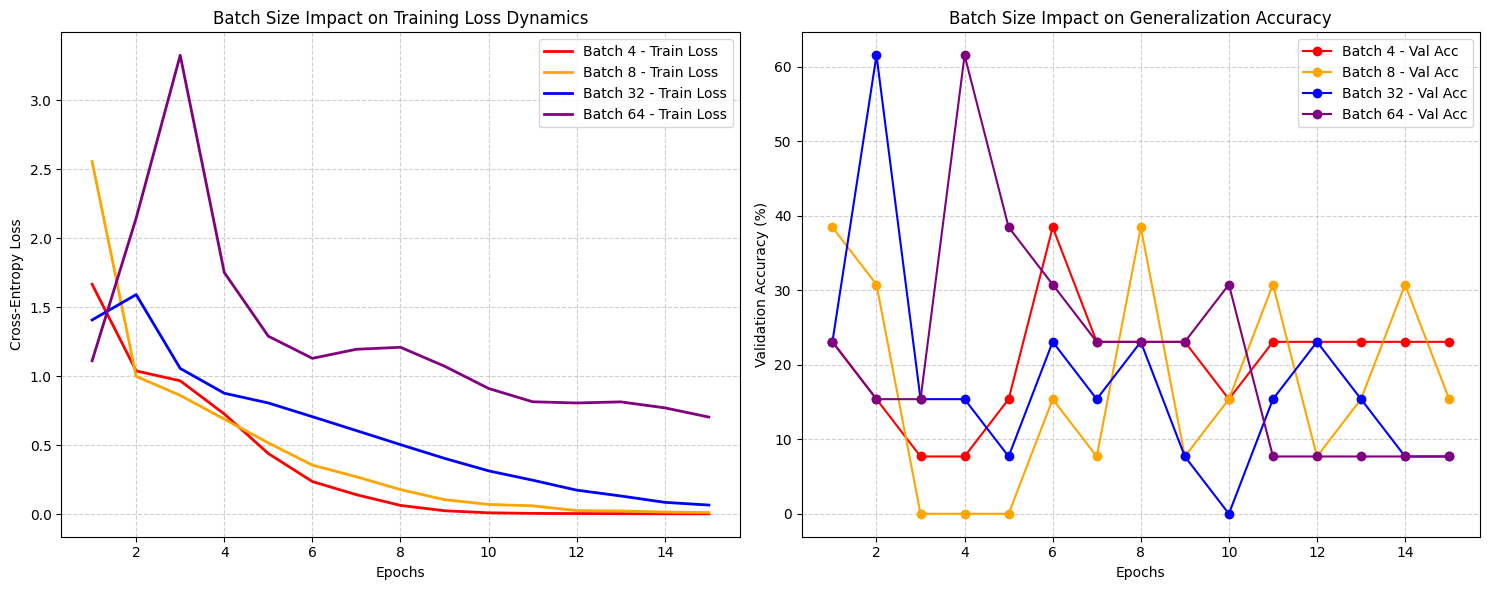


             BATCH SIZE EXPERIMENT METRICS TABLE
Batch Size Configuration  | Final Train Acc | Final Val Acc 
-------------------------------------------------------
Batch Size = 4                  | 100.00% | 23.08%
Batch Size = 8                  | 100.00% | 15.38%
Batch Size = 32                 | 98.39% | 7.69%
Batch Size = 64                 | 70.97% | 7.69%


In [10]:
# =====================================================================
# QUICK FIX CELL: PLOT ACCURACY WITHOUT RETRAINING
# =====================================================================
import matplotlib.pyplot as plt

epochs_range = range(1, 16)
target_batches = [4, 8, 32, 64]

# Fix color mapping explicitly using strings to avoid matplotlib formatting issues
color_map = {'batch_4': 'red', 'batch_8': 'orange', 'batch_32': 'blue', 'batch_64': 'purple'}

plt.figure(figsize=(15, 6))

# 1. Left Plot: Training Loss
plt.subplot(1, 2, 1)
for b in target_batches:
    key = f'batch_{b}'
    plt.plot(epochs_range, batch_results[key]['train_loss'],
             color=color_map[key], linestyle='-', linewidth=2, label=f'Batch {b} - Train Loss')
plt.title('Batch Size Impact on Training Loss Dynamics')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Right Plot: Validation Accuracy (Fixed)
plt.subplot(1, 2, 2)
for b in target_batches:
    key = f'batch_{b}'
    plt.plot(epochs_range, batch_results[key]['val_acc'],
             color=color_map[key], marker='o', linestyle='-', linewidth=1.5, label=f'Batch {b} - Val Acc')
plt.title('Batch Size Impact on Generalization Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('multi_batch_size_comparison_fixed.png', dpi=300)
plt.show()

# Print Table Output using your existing trained variables
print("\n" + "="*55)
print("             BATCH SIZE EXPERIMENT METRICS TABLE")
print("="*55)
print(f"{'Batch Size Configuration':<25} | {'Final Train Acc':<14} | {'Final Val Acc':<14}")
print("-"*55)
for b in target_batches:
    key = f'batch_{b}'
    print(f"Batch Size = {b:<12}       | {batch_results[key]['train_acc'][-1]:.2f}% | {batch_results[key]['val_acc'][-1]:.2f}%")
print("="*55)